In [2]:
# Configuration and File Paths
import sys
import time
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import geopandas as gpd

from config import get_config, get_development_config, validate_config, setup_directories, print_config_summary
from src.simulation import simulate_asset_damage_recovery_access_optimized
from src.data_loader import load_hazard_maps, load_electricity_assets
from src.visualization import *
import src.grid_based_accessibility_hex as grid_hex
from src.hazard_analysis_electricity import find_hazard_value_at_points_optimized, _fallback_rasterio_method
# #TODO: import and run sensitivity analysis
#!pip install contextily


c:\Users\meije_le\AppData\Local\miniforge3\envs\ra2ce_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Get configuration (currently from config.py)
# config = get_config()
config = get_config()

# Validate and setup
is_valid, missing_dirs = validate_config(config)
setup_directories(config)

# Print summary
print_config_summary(config)

# Handle validation results
if missing_dirs:
    print(f"\nWarning: Missing directories: {missing_dirs}")
else:
    print("\nAll data directories found successfully!")

# Set the hazard extraction method constant
HAZARD_EXTRACTION_METHOD = config['analysis_config']['hazard_extraction_method']
print(f"Hazard extraction method set to: {HAZARD_EXTRACTION_METHOD}")



Configuration Summary
Root directory: c:\python\powerpath
Assets data: N:\Projects\11209000\11209175\B. Measurements and calculations\Data\full_run\electricity
Hazard data: c:\python\powerpath\data\static\hazard\processed
Interim directory: c:\python\powerpath\data\interim\interim_processed
Output directory: c:\python\powerpath\data\output\output_processed

Simulation Configuration:
  number_repair_crews: 20
  repair_crew_assignment_method: islands
  flood_threshold: 0.2
  verbose: True
  accessibility_model: None

Recovery Parameters:
  repair_time_coefficients: [702.72, 3.14, 1.9891]
  damage_ratio_coefficients: (0.0468, 0.0077)
  time_step_hours: 1
  damage_threshold: 0.01
  repair_threshold: 2.0

Analysis Configuration:
  hazard_extraction_method: max
  max_simulation_days: None
  cache_enabled: True
  performance_monitoring: False

All data directories found successfully!
Hazard extraction method set to: max


In [4]:
# Load data
print("Loading electricity assets...")
gdf_assets = load_electricity_assets(config['electricity_dir'], asset_types=['ls', 'msls'])

print("\nLoading hazard maps...")
hazard_maps = load_hazard_maps(config['hazard_dir'], max_days=10)  
print("Data loading completed!")
print(f"\nHazard maps loaded:")
for i, hm in enumerate(hazard_maps):
    if i < 3:
        print(f"  -{hm}")
    elif i == 3:
        print(f"  and {len(hazard_maps) - 3} more")
        break




Loading electricity assets...
Found 2 electricity station files matching types ['ls', 'msls']
All .shp files in directory: ['msls_stations_ZH_Delfland_2.shp', 'ls_stations_ZH_Delfland_2.shp', 'ms_stations_ZH_Delfland_2.shp']
Files with 'station': ['msls_stations_ZH_Delfland_2.shp', 'ls_stations_ZH_Delfland_2.shp', 'ms_stations_ZH_Delfland_2.shp']
Final matched files: ['msls_stations_ZH_Delfland_2.shp', 'ls_stations_ZH_Delfland_2.shp']
Loading electricity assets from msls_stations_ZH_Delfland_2.shp
Loaded 5858 msls assets
Loading electricity assets from ls_stations_ZH_Delfland_2.shp
Loaded 5041 ls assets
Combined total: 10899 electricity assets
Asset types: {'msls': 5858, 'ls': 5041}

Loading hazard maps...
Found 3 hazard map files
Data loading completed!

Hazard maps loaded:
  -c:\python\powerpath\data\static\hazard\processed\clipped_hazard_map.tif
  -c:\python\powerpath\data\static\hazard\processed\clipped_hazard_map_larger.tif
  -c:\python\powerpath\data\static\hazard\processed\delfl

In [5]:
timesteps = np.arange(0, len(hazard_maps) * 24)  # 24 hours per day
day_counter = timesteps // 24  # Integer division to get day count

In [6]:
import numpy as np

# Generate timesteps: 24 hours per day
timesteps = np.arange(0, len(hazard_maps) * 24)
temp_gdf = gdf_assets.copy()
_config = get_config()

if hazard_maps:
    hazard_dir = Path(hazard_maps[0]).parent
    hazard_dir_name = hazard_dir.name
    print(f"Using hazard directory for cache naming: {hazard_dir_name}")
else:
    hazard_dir = None
    hazard_dir_name = "unknown"

for timestep in timesteps:
    day_counter = timestep // 24
    day_counter_str = str(day_counter).zfill(2)

    # Process hazard map every 24 timesteps (i.e., once per day)
    if timestep % 24 == 0:
        if day_counter >= len(hazard_maps):
            break  # No more hazard maps available

        hazard_map = hazard_maps[day_counter]
        haz_col_str = f'EV{day_counter}_ma'

        # Update hazard values
        temp_gdf = find_hazard_value_at_points_optimized(
            hazard_map_path=hazard_maps[day_counter],
            gdf_assets=temp_gdf,
            day_counter=day_counter,
            extraction_method=_config['analysis_config']['hazard_extraction_method'],
            #hazard_cache=hazard_extraction_cache,
            hazard_dir=hazard_dir
        )

        haz_val_str = f'hazard_value_{day_counter_str}'
        if haz_val_str in temp_gdf.columns:
            current_hazard_values = temp_gdf[haz_val_str].fillna(0.0).values
        else:
            current_hazard_values = temp_gdf[haz_col_str].fillna(0.0).values

    temp_gdf["asset_id"] = temp_gdf.index
    temp_gdf["geometry"] = temp_gdf.geometry.centroid


Using hazard directory for cache naming: processed
Extracting hazard values using method: max


C:\Users\meije_le\AppData\Local\Temp\ipykernel_34260\3130158970.py:45: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  temp_gdf["geometry"] = temp_gdf.geometry.centroid


Extracting hazard values using method: max


C:\Users\meije_le\AppData\Local\Temp\ipykernel_34260\3130158970.py:45: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  temp_gdf["geometry"] = temp_gdf.geometry.centroid


Extracting hazard values using method: max


C:\Users\meije_le\AppData\Local\Temp\ipykernel_34260\3130158970.py:45: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  temp_gdf["geometry"] = temp_gdf.geometry.centroid


In [7]:
def analyze_flooding(gdf, threshold=0.2):
    """
    Adds two columns to the GeoDataFrame:
    - 'days_flooded': number of hazard columns where value exceeds the threshold
    - 'first_flood_day': name of the first column where flooding is detected

    Parameters:
    - gdf: GeoDataFrame containing hazard columns
    - threshold: float, the flooding threshold (default is 0.2)

    Returns:
    - GeoDataFrame with added columns
    """
    # Identify hazard columns
    hazard_columns = [col for col in gdf.columns if col.startswith('hazard_value_')]

    # Initialize new columns
    gdf['days_flooded'] = 0
    gdf['first_flood_day'] = None

    # Process each row
    for idx, row in gdf.iterrows():
        flooded_days = 0
        first_day = None

        for col in hazard_columns:
            if row[col] > threshold:
                flooded_days += 1
                if first_day is None:
                    first_day = col
        gdf.at[idx, 'days_flooded'] = flooded_days
        gdf.at[idx, 'first_flood_day'] = first_day

    return gdf


In [8]:
from pathlib import Path
from config import get_development_config
from src.data_loader import load_electricity_assets, load_hazard_maps
from src.hazard_analysis_electricity import find_hazard_value_at_points_optimized
from src.damage_recovery import default_damage_ratio_function, default_repair_time_function, default_fragility_function
import numpy as np

_config = get_development_config()
electricity_assets_path = _config['electricity_dir']
gdf_assets = load_electricity_assets(electricity_assets_path, ['msls'])
hazard_maps = load_hazard_maps(_config['hazard_dir'], max_days=10)
 
 
temp_gdf = temp_gdf
_config = get_development_config()
 
for hm in hazard_maps:
    day_counter = hazard_maps.index(hm)
    temp_gdf = find_hazard_value_at_points_optimized(
        hazard_map_path=hazard_maps[day_counter],
        gdf_assets=temp_gdf,
        day_counter=day_counter,
        extraction_method='max')
 
 
# Find damage ratios
dr_coefs = _config['recovery_parameters']['damage_ratio_coefficients']
dr_max = np.zeros_like(temp_gdf['EV0_ma'])
 
for hm in hazard_maps:
    day_counter = hazard_maps.index(hm)
    hazard_column = f'EV{day_counter}_ma'
    dr_max = np.maximum(dr_max, default_damage_ratio_function(temp_gdf[hazard_column], coefficients=dr_coefs))
 
temp_gdf['damage_ratio'] = dr_max
 
 
# Find repair times
rt_coefs = _config['recovery_parameters']['repair_time_coefficients']
temp_gdf['repair_time'] = default_repair_time_function(temp_gdf['damage_ratio'], coefficients=rt_coefs)

Found 1 electricity station files matching types ['msls']
All .shp files in directory: ['ls_stations_test_samples.shp', 'msls_stations_test_samples.shp', 'ms_stations_test_samples.shp']
Files with 'station': ['ls_stations_test_samples.shp', 'msls_stations_test_samples.shp', 'ms_stations_test_samples.shp']
Final matched files: ['msls_stations_test_samples.shp']
Loading electricity assets from msls_stations_test_samples.shp
Loaded 245 msls assets
Combined total: 245 electricity assets
Asset types: {'msls': 245}
Found 10 hazard map files
Extracting hazard values using method: max
Extracting hazard values using method: max
Extracting hazard values using method: max
Extracting hazard values using method: max
Extracting hazard values using method: max
Extracting hazard values using method: max
Extracting hazard values using method: max
Extracting hazard values using method: max
Extracting hazard values using method: max
Extracting hazard values using method: max


In [9]:
temp_gdf_msls = temp_gdf[temp_gdf['type'] == 'msls'].copy()
temp_gdf_msls_duration = analyze_flooding(temp_gdf_msls, threshold=0.2)

In [10]:
temp_gdf_msls_duration

,MiddenL_ID,geometry,type,Laagspa_ID,EV0_ma,hazard_value_00,asset_id,EV1_ma,hazard_value_01,EV2_ma,...,EV7_ma,hazard_value_07,EV8_ma,hazard_value_08,EV9_ma,hazard_value_09,damage_ratio,repair_time,days_flooded,first_flood_day
0,None,POINT (4.51782 51.88862),msls,NaN,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0077,2.054942,0,None
1,None,POINT (4.51782 51.88862),msls,NaN,0.0,0.0,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0077,2.054942,0,None
2,None,POINT (4.50668 51.88905),msls,NaN,0.0,0.0,2,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0077,2.054942,0,None
3,None,POINT (4.50668 51.88905),msls,NaN,0.0,0.0,3,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0077,2.054942,0,None
4,None,POINT (4.50830 51.88946),msls,NaN,0.0,0.0,4,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0077,2.054942,0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5853,None,POINT (4.49521 52.08868),msls,NaN,0.0,0.0,5853,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0077,2.054942,0,None
5854,None,POINT (4.47172 52.09624),msls,NaN,0.0,0.0,5854,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0077,2.054942,0,None
5855,None,POINT (4.47976 52.09941),msls,NaN,0.0,0.0,5855,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0077,2.054942,0,None
5856,None,POINT (4.46906 52.10015),msls,NaN,0.0,0.0,5856,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0077,2.054942,0,None


In [11]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import geopandas as gpd
import contextily as ctx

def animate_flooded_assets(gdf, threshold=0.2):
    """
    Creates an animated spatial map showing which stations are flooded on each day.
    Flooding is determined by hazard columns with values above the threshold.
    A CartoDB Positron basemap is added using contextily and reprojected to EPSG:28992.

    Parameters:
    - gdf: GeoDataFrame in EPSG:28992 containing hazard columns and geometry
    - threshold: float, the flooding threshold
    """
    # Identify hazard columns and extract day indices
    hazard_columns = [col for col in gdf.columns if col.startswith('hazard_value_')]
    day_indices = sorted(set(int(col.split('_')[-1]) for col in hazard_columns))

    # Check if any station is flooded on any day
    flooded_any_day = any((gdf[col] > threshold).any() for col in hazard_columns)
    if not flooded_any_day:
        print("No stations exceed the flooding threshold on any day.")
        return None

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 8))

    def update(day):
        ax.clear()
        day_str = str(day).zfill(2)
        hazard_col = f'hazard_value_{day_str}'
        flooded = gdf[gdf[hazard_col] > threshold]

        # Plot all stations
        gdf.plot(ax=ax, color='lightgrey', edgecolor='black')
        # Plot flooded stations
        if not flooded.empty:
            flooded.plot(ax=ax, color='red', markersize=50)

        # Add CartoDB Positron basemap reprojected to EPSG:28992
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=gdf.crs.to_string())

        ax.set_title(f'Dag {day + 1}: Overstroomde Stations')
        ax.set_axis_off()

    ani = animation.FuncAnimation(fig, update, frames=day_indices, repeat=True, blit=False, interval=1000)
    ani.save(r"C:\python\powerpath\data\flooded_assets.gif", writer="pillow")

    plt.show()

    return ani


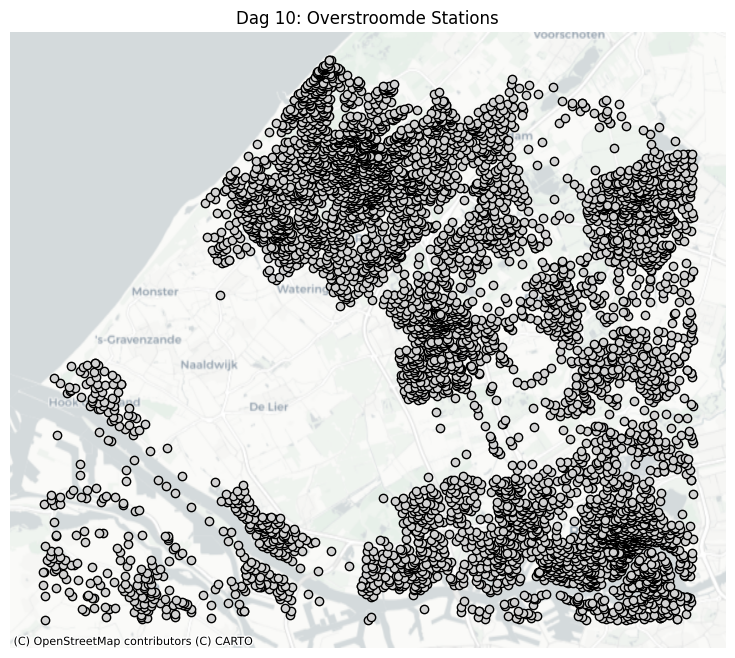

In [12]:
animate_flooded_assets(temp_gdf_msls_duration)

In [ ]:
temp_gdf_msls_duration.explore(column='days_flooded',
                                cmap='OrRd',tiles='CartoDB positron')

In [ ]:
temp_gdf_msls_duration.explore(column='damage_ratio', cmap='OrRd',tiles='CartoDB positron')

In [ ]:
def create_voronoi_boundary(gdf_assets, buffer=200):
    # Convert to projected CRS to find the centroids and buffer in meters
    projected_centroids = gdf_assets.to_crs("EPSG:28992").geometry.centroid
    centroids_union = projected_centroids.unary_union
    convex_hull = centroids_union.convex_hull.buffer(buffer)
    return convex_hull  
 
 
def create_voronoi_for_asset_type(gdf_assets, asset_type):
    """Create Voronoi polygons for a specific asset type"""
    from scipy.spatial import Voronoi
    from shapely.geometry import Polygon
    import geopandas as gpd
   
    # Filter assets by type and get centroids
    assets_filtered = gdf_assets[gdf_assets['type'] == asset_type].copy()
    assets_filtered['geometry'] = assets_filtered['geometry'].to_crs("EPSG:28992").centroid
   
    # Create Voronoi polygons with asset IDs
    points = assets_filtered.geometry.apply(lambda geom: (geom.x, geom.y)).tolist()
    asset_ids = assets_filtered.index.tolist()
   
    vor = Voronoi(points)
    polygons = []
    valid_asset_ids = []
   
    for point_idx, region_idx in enumerate(vor.point_region):
        region = vor.regions[region_idx]
        if not -1 in region and len(region) > 0:
            polygon = Polygon([vor.vertices[i] for i in region])
            clipped_polygon = polygon.intersection(create_voronoi_boundary(gdf_assets))
 
            if clipped_polygon.is_empty:
                continue
 
            if not clipped_polygon.is_valid:
                clipped_polygon = clipped_polygon.make_valid()
               
            polygons.append(clipped_polygon)
            valid_asset_ids.append(asset_ids[point_idx])
   
    voronoi_gdf = gpd.GeoDataFrame(geometry=polygons)
    voronoi_gdf['geometry']=voronoi_gdf["geometry"]
    voronoi_gdf = voronoi_gdf.set_crs(assets_filtered.crs)
    voronoi_gdf['asset_id'] = valid_asset_ids
   
    return voronoi_gdf

In [ ]:
voronoi_geometry = create_voronoi_for_asset_type(temp_gdf, 'msls')
# Drop the geometry column from temp_gdf before merging
temp_gdf_no_geom = temp_gdf.drop(columns='geometry')

# Merge with voronoi_geometry
voronoi_assets_hazard = voronoi_geometry.merge(temp_gdf_no_geom, left_on='asset_id', right_index=True)


In [ ]:
voronoi_assets_hazard

,asset_id,geometry,asset_id_x,MiddenL_ID,type,EV0_ma,hazard_value_00,asset_id_y,EV1_ma,hazard_value_01,...,EV6_ma,hazard_value_06,EV7_ma,hazard_value_07,EV8_ma,hazard_value_08,EV9_ma,hazard_value_09,damage_ratio,repair_time
0,4,"POLYGON ((82101.100 453570.398, 81709.220 4535...",4,None,msls,0.0,0.0,4,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.007700,2.054942
1,6,"POLYGON ((81533.029 453910.343, 81555.285 4539...",6,None,msls,0.0,0.0,6,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.007700,2.054942
2,7,"POLYGON ((81983.721 453962.999, 82013.271 4539...",7,None,msls,0.0,0.0,7,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.007700,2.054942
3,8,"POLYGON ((81455.108 453890.051, 81308.074 4537...",8,None,msls,0.0,0.0,8,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.007700,2.054942
4,9,"POLYGON ((81241.204 453957.562, 81222.665 4538...",9,None,msls,0.0,0.0,9,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.007700,2.054942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224,239,"POLYGON ((81444.834 455723.672, 81377.522 4557...",239,None,msls,0.0,0.0,239,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.007700,2.054942
225,240,"POLYGON ((81664.470 455918.108, 81456.781 4558...",240,None,msls,0.0,0.0,240,0.477603,0.477603,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.036604,3.045569
226,241,"POLYGON ((81100.360 455819.102, 80948.914 4558...",241,None,msls,0.0,0.0,241,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.007700,2.054942
227,242,"POLYGON ((81344.964 455791.550, 81252.485 4558...",242,None,msls,0.0,0.0,242,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.007700,2.054942


In [ ]:
# Population
import geopandas as gpd
root_dir = config['root_dir']
population_data_path = Path(r"C:\python\Use_case_stedin\population\cbs_population_data_fixed_geometry.gpkg")
assert population_data_path.exists()


In [ ]:
buffer_distance_meters = 1000
population_buffer = study_area.buffer(buffer_distance_meters)
population_buffer.set_crs("EPSG:28992")


NameError: name 'study_area' is not defined

In [ ]:
def create_voronoi_for_asset_type(gdf_assets, asset_type, bounding_box):
    """Create Voronoi polygons for a specific asset type"""
    from scipy.spatial import Voronoi
    from shapely.geometry import Polygon
    import geopandas as gpd
    
    # Filter assets by type and get centroids
    assets_filtered = gdf_assets[gdf_assets['type'] == asset_type].copy()
    assets_filtered['geometry'] = assets_filtered['geometry'].to_crs("EPSG:28992").centroid
    
    # Create Voronoi polygons with asset IDs
    points = assets_filtered.geometry.apply(lambda geom: (geom.x, geom.y)).tolist()
    asset_ids = assets_filtered.index.tolist()
    
    vor = Voronoi(points)
    polygons = []
    valid_asset_ids = []
    
    for point_idx, region_idx in enumerate(vor.point_region):
        region = vor.regions[region_idx]
        if not -1 in region and len(region) > 0:
            polygon = Polygon([vor.vertices[i] for i in region])
            clipped_polygon = polygon.intersection(bounding_box)
            
            if not clipped_polygon.is_empty and clipped_polygon.is_valid:
                polygons.append(clipped_polygon)
                valid_asset_ids.append(asset_ids[point_idx])
    
    voronoi_gdf = gpd.GeoDataFrame(geometry=polygons)
    voronoi_gdf = voronoi_gdf.set_crs(assets_filtered.crs)
    voronoi_gdf['asset_id'] = valid_asset_ids
    
    return voronoi_gdf

def assign_impact_metric_to_voronoi(voronoi_gdf, impact_data, impact_column='aantal_inwoners'):
    """
    Assign impact metric to Voronoi polygons using area-weighted intersection
    
    Parameters:
    -----------
    voronoi_gdf : GeoDataFrame
        Voronoi polygons with asset_id column
    impact_data : GeoDataFrame
        Impact data (e.g., population, economic value, etc.)
    impact_column : str
        Column name containing the impact metric values
    
    Returns:
    --------
    GeoDataFrame : Voronoi polygons with assigned_impact_metric column
    """
    import geopandas as gpd
    
    voronoi = voronoi_gdf.copy()
    impact_grid = impact_data.copy()
    
    # Ensure CRS match
    impact_grid = impact_grid.to_crs(voronoi.crs)
    
    # Calculate area of each impact grid cell
    impact_grid["cell_area"] = impact_grid.geometry.area
    
    # Preserve Voronoi index before overlay
    voronoi["voronoi_index"] = voronoi.index
    
    # Spatial intersection
    intersections = gpd.overlay(impact_grid, voronoi, how="intersection")
    
    # Calculate area of intersection
    intersections["intersect_area"] = intersections.geometry.area
    
    # Area-weighted impact metric
    intersections["weighted_impact_metric"] = (
        intersections[impact_column] * intersections["intersect_area"] / intersections["cell_area"]
    )
    
    # Aggregate impact metric by Voronoi index
    impact_by_voronoi = (
        intersections.groupby("voronoi_index")["weighted_impact_metric"].sum().reset_index()
    )
    
    # Merge back to Voronoi polygons
    voronoi = voronoi.merge(impact_by_voronoi, on="voronoi_index", how="left")
    voronoi = voronoi.rename(columns={"weighted_impact_metric": "assigned_impact_metric"})
    voronoi['assigned_impact_metric'] = voronoi['assigned_impact_metric'].fillna(0)
    
    return voronoi

def filter_timesteps_by_asset_type(gdf_assets, timesteps_df, asset_type):
    """Filter timesteps DataFrame by asset type"""
    gdf_assets_filt = gdf_assets[gdf_assets['type'] == asset_type]
    timesteps_df_filt = timesteps_df[timesteps_df['asset_id'].isin(gdf_assets_filt.index)]
    return timesteps_df_filt

def calculate_affected_impact_by_timestep(timesteps_df, voronoi_gdf, impact_metric_column='assigned_impact_metric'):
    """
    Calculate affected impact metric for each asset at each timestep
    
    Parameters:
    -----------
    timesteps_df : DataFrame
        Timestep data with operational status
    voronoi_gdf : GeoDataFrame
        Voronoi polygons with impact metric assignments
    impact_metric_column : str
        Column name containing the impact metric values
        
    Returns:
    --------
    dict : Nested dictionary {asset_id: {timestep: affected_impact}}
    """
    import pandas as pd
    
    # Create mapping from asset_id to impact metric
    impact_by_asset = dict(zip(voronoi_gdf['asset_id'], voronoi_gdf[impact_metric_column]))
    
    # Add impact metric data to timesteps_df
    timesteps_df = timesteps_df.copy()
    timesteps_df['impact_metric'] = timesteps_df['asset_id'].map(impact_by_asset)
    
    # Calculate affected impact metric: (1-operational) * impact_metric
    timesteps_df['affected_impact'] = (1 - timesteps_df['operational']) * timesteps_df['impact_metric']
    
    # Group by asset_id and timestep, then convert to nested dict
    grouped = timesteps_df.groupby(['asset_id', 'timestep'])['affected_impact'].first()
    
    # Convert to nested dictionary structure
    impact_by_asset_ts = {}
    for (asset_id, timestep), affected_impact in grouped.items():
        if asset_id not in impact_by_asset_ts:
            impact_by_asset_ts[asset_id] = {}
        impact_by_asset_ts[asset_id][timestep] = affected_impact
    
    return impact_by_asset_ts

def find_most_impactful_assets(impact_affected_dict, top_percent=None, min_impact=0):
    """
    Identify most impactful assets based on total impact
    
    Parameters:
    -----------
    impact_affected_dict : dict
        Nested dictionary with impact data by asset and timestep
    top_percent : float, optional
        Percentage of top impactful assets to select (e.g., 0.05 for 5%)
    min_impact : float
        Minimum impact threshold for selection
        
    Returns:
    --------
    tuple : (selected_asset_ids, detailed_impact_dict, all_asset_impacts)
    """
    import pandas as pd
    
    # Calculate total impact per asset across all timesteps
    asset_total_impacts = {}
    for asset_id, timestep_data in impact_affected_dict.items():
        total_impact = sum(impact for impact in timestep_data.values() if not pd.isna(impact))
        asset_total_impacts[asset_id] = total_impact
    
    # Sort assets by total impact (descending)
    sorted_assets = sorted(asset_total_impacts.items(), key=lambda x: x[1], reverse=True)
    
    # Select assets based on criteria
    if top_percent:
        count = max(1, int(len(sorted_assets) * top_percent))
        selected_assets = [asset_id for asset_id, impact in sorted_assets[:count] if impact > 0]
    else:
        # Select all assets with impact > min_impact
        selected_assets = [asset_id for asset_id, impact in sorted_assets if impact > min_impact]
    
    # Create detailed impact dictionary
    mia = {
        asset: {
            'total_impact': asset_total_impacts[asset],
            'timestep_data': impact_affected_dict[asset]
        } 
        for asset in selected_assets
    }
    
    return selected_assets, mia, asset_total_impacts

def prepare_visualization_data(asset_ids, gdf_assets, voronoi_gdf, mia_dict, timesteps_df, 
                              impact_metric_column='assigned_impact_metric'):
    """
    Prepare data for visualization (sizes, colors, impact metrics, etc.)
    
    Parameters:
    -----------
    asset_ids : list
        List of selected asset IDs
    gdf_assets : GeoDataFrame
        Assets geodataframe
    voronoi_gdf : GeoDataFrame
        Voronoi polygons with impact metric
    mia_dict : dict
        Most impactful assets dictionary
    timesteps_df : DataFrame
        Timestep data
    impact_metric_column : str
        Column name for the impact metric
        
    Returns:
    --------
    dict : Dataset dictionary ready for visualization
    """
    import pandas as pd
    
    # Get GeoDataFrame for selected assets
    selected_gdf = gdf_assets[gdf_assets.index.isin(asset_ids)]
    
    # Calculate visualization data
    total_impacts = []
    asset_impact_metrics = []
    
    for asset_id in selected_gdf.index:
        # Get total impact for color
        total_impacts.append(mia_dict[asset_id]['total_impact'])
        
        # Get impact metric for size from voronoi data
        matching_voronoi = voronoi_gdf[voronoi_gdf['asset_id'] == asset_id]
        if len(matching_voronoi) > 0:
            asset_impact_metrics.append(matching_voronoi[impact_metric_column].iloc[0])
        else:
            asset_impact_metrics.append(0)
    
    # Normalize sizes based on impact metric (scale between 10-210 for visibility)
    if max(asset_impact_metrics) > 0:
        max_metric = max(asset_impact_metrics)
        normalized_sizes = [metric / max_metric * 200 + 10 for metric in asset_impact_metrics]
    else:
        normalized_sizes = [200] * len(asset_impact_metrics)
    
    # Calculate summary statistics
    sum_by_timestep = {}
    timesteps_filtered = timesteps_df[timesteps_df['asset_id'].isin(asset_ids)]
    
    for timestep in timesteps_filtered['timestep'].unique():
        total_affected = 0
        for asset_id in voronoi_gdf['asset_id']:
            if asset_id in mia_dict:
                impact_value = mia_dict[asset_id]['timestep_data'].get(timestep, 0)
                if not pd.isna(impact_value):
                    total_affected += impact_value
        sum_by_timestep[timestep] = total_affected
    
    worst_timestep = max(sum_by_timestep.keys(), key=lambda x: sum_by_timestep[x]) if sum_by_timestep else 0
    worst_impact = sum_by_timestep.get(worst_timestep, 0)
    
    return {
        'gdf': selected_gdf,
        'voronoi': voronoi_gdf,
        'sizes': normalized_sizes,
        'impacts': total_impacts,
        'impact_metrics': asset_impact_metrics,  # Generic term instead of 'populations'
        'mia': mia_dict,
        'worst_timestep': worst_timestep,
        'worst_impact': worst_impact,
        'centroids': selected_gdf.to_crs(epsg=3857).centroid
    }

def analyze_asset_impact_metric(asset_types, gdf_assets, timesteps_df, impact_data, bounding_box, 
                               impact_column='aantal_inwoners', top_percent=0.05, verbose=False):
    """
    Main orchestration function that analyzes impact metrics for multiple asset types
    
    Parameters:
    -----------
    asset_types : list
        List of asset type strings (e.g., ['msls', 'ls'])
    gdf_assets : GeoDataFrame
        Assets geodataframe
    timesteps_df : DataFrame  
        Timestep simulation results
    impact_data : GeoDataFrame
        Impact metric data (population, economic value, etc.)
    bounding_box : Polygon
        Study area bounding box
    impact_column : str
        Column name containing the impact metric values
    top_percent : float
        Percentage of top impactful assets to select (default 0.05 = 5%)
    verbose : bool
        Verbose output for debugging

    Returns:
    --------
    dict : Dictionary with asset_type as keys and dataset dictionaries as values
    """
    results = {}
    
    for asset_type in asset_types:
        print(f"\nProcessing {asset_type.upper()} assets...")
        
        # Create Voronoi polygons
        voronoi_gdf = create_voronoi_for_asset_type(gdf_assets, asset_type, bounding_box)
        if verbose:
            print(f"  Created {len(voronoi_gdf)} Voronoi polygons")

        # Assign impact metric to Voronoi polygons
        voronoi_with_impact = assign_impact_metric_to_voronoi(voronoi_gdf, impact_data, impact_column)
        if verbose:
            print(f"  Assigned impact metric to Voronoi polygons")

        # Filter timesteps for this asset type
        timesteps_filtered = filter_timesteps_by_asset_type(gdf_assets, timesteps_df, asset_type)
        if verbose:
            print(f"  Filtered to {len(timesteps_filtered)} timestep records")

        # Calculate affected impact metric by timestep
        impact_affected = calculate_affected_impact_by_timestep(timesteps_filtered, voronoi_with_impact)
        
        # Find most impactful assets
        impactful_assets, mia_dict, all_impacts = find_most_impactful_assets(
            impact_affected, top_percent=top_percent
        )
        if verbose:
            print(f"  Found {len(impactful_assets)} most impactful assets")

        # Prepare dataset for visualization
        dataset = prepare_visualization_data(
            impactful_assets, gdf_assets, voronoi_with_impact, mia_dict, timesteps_filtered
        )
        
        # Add asset type identifier
        dataset['asset_type'] = asset_type.upper()
        
        results[asset_type] = dataset
        
        print(f"  Total impact: {sum(dataset['impacts']):.1f} impact-hours")
    
    return results